# 分类指标
在机器学习的世界里，构建一个分类模型只是第一步。就像一位医生不能仅凭感觉判断病情，我们也需要一套科学的体检指标来评估模型的健康状况。这些指标就是分类指标，它们能告诉我们模型预测得有多准、哪里做得好、哪里还有不足。

今天，我们将一起学习这些至关重要的评估工具。

-----

## 为什么需要分类指标？
在分类任务中，我们的目标是让模型能够正确地将数据点分到不同的类别中。虽然我们可以通过观察模型的预测结果来判断它的表现，但这往往是主观的、片面的。分类指标提供了一种客观、量化的方法来评估模型的性能，帮助我们更好地理解模型的优缺点，并指导我们进行改进。



## 常见的分类指标
1. **准确率（Accuracy）**：表示模型正确预测的样本占总样本的比例。适用于类别分布均衡的情况。
2. **精确率（Precision）**：表示模型预测为正类的样本中实际为正类的比例。适用于关注假阳性（False Positive）较多的情况。
3. **召回率（Recall）**：表示模型预测为正类的样本中实际为正类的比例。适用于关注假阴性（False Negative）较多的情况。
4. **F1-score**：精确率和召回率的调和平均数，综合考虑了模型的精确性和召回能力。适用于类别不平衡的情况。
5. **ROC曲线和AUC值**：ROC曲线展示了模型在不同阈值下的性能，AUC值则量化了模型区分正负类的能力。

想象一下，你训练了一个模型来识别邮件是否为垃圾邮件。模型对 100 封邮件进行了预测，你可能会问：

- "它预测对了多少封？" -> 这引出了准确率。
- "在真正的垃圾邮件中，它找出了多少？" -> 这引出了召回率。
- "它说是垃圾邮件的，有多少真的是垃圾？" -> 这引出了精确率。

如果只用对了多少来评判，就像只用考试总分评价学生，会忽略很多重要信息。不同的业务场景关注的重点不同：

- 疾病诊断：我们更关心别漏掉任何一个病人（高召回率），哪怕多检查一些健康的人（牺牲一些精确率）。
- 垃圾邮件过滤：我们更关心别把重要邮件扔进垃圾箱（高精确率），哪怕漏掉一些垃圾邮件（牺牲一些召回率）。
因此，我们需要一系列指标，从不同角度全面评估模型性能。


----

## 核心概念 : 混淆矩阵（Confusion Matrix）
几乎所有分类指标都源于一个强大的工具——混淆矩阵。它是理解模型预测结果的"全景地图"。

### 什么是混淆矩阵？
它是一个表格，展示了模型预测结果与真实标签之间的所有四种可能情况
|               | 预测为正类 | 预测为负类 |
|---------------|-------------|-------------|
| **实际为正类** | 真阳性（TP）  | 假阴性（FN）  |
| **实际为负类** | 假阳性（FP）  | 真阴性（TN）  |
- **真阳性（TP）**：模型正确地预测为正类的样本数量。
- **假阴性（FN）**：模型错误地预测为负类的正类样本数量。
- **假阳性（FP）**：模型错误地预测为正类的负类样本数量。
- **真阴性（TN）**：模型正确地预测为负类的样本数量。

In [8]:
# 一个混淆矩阵的示例（以二分类"是/否垃圾邮件"为例）
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 假设我们有真实标签和预测标签
y_true = [1, 0, 1, 1, 0, 0, 1, 0, 0, 1]  # 1代表垃圾邮件，0代表正常邮件
y_pred = [1, 0, 0, 1, 0, 0, 1, 1, 0, 1]  # 模型的预测结果

# 计算混淆矩阵
cm = confusion_matrix(y_true, y_pred)
print("混淆矩阵：")
print(cm)
# 输出可能为：
# [[4 1]   # 真实为0（正常），预测为0的有4个（TN），预测为1的有1个（FP）
#  [1 4]]  # 真实为1（垃圾），预测为0的有1个（FN），预测为1的有4个（TP）

混淆矩阵：
[[4 1]
 [1 4]]


为了更好的理解 , 我们将其可视化

![alt text](dd5abfe2-2088-4b43-98fa-cd0fbf1de8eb.png)

-----

## 三 . 核心分类指标详解
有了混淆矩阵，我们就可以像用公式计算一样，得出各种评估指标。



### 1. 准确率（Accuracy） - 最直观的指标
准确率衡量了模型预测正确的样本占总样本的比例。
$$\text{准确率} = \frac{TP + TN}{TP + TN + FP + FN}$$
虽然准确率简单易懂，但在类别不平衡的情况下可能会产生误导。例如，在一个99%是负类的任务中，即使模型全部预测为负类，准确率也能达到99%，但模型实际上没有任何预测能力。

### 2. 精确率 - "宁缺毋滥"的指标
精确率关注模型预测出的正例中有多少是真正的正例。它衡量了预测结果的可靠性或精准度。

$$\text{精确率} = \frac{TP}{TP + FP}$$

问题：在我们预测为垃圾邮件的邮件中，有多少真的是垃圾邮件？ 高精确率意味着：模型说"这是垃圾邮件"时，可信度很高。

### 3. 召回率 - "宁可错杀"的指标
召回率关注所有真实的正例中被模型找出了多少。它衡量了模型发现正例的能力。

$$\text{召回率} = \frac{TP}{TP + FN}$$

问题：在所有真正的垃圾邮件中，我们找出了多少？ 高召回率意味着：模型很少漏掉真正的垃圾邮件

### 4. F1 分数 - 精确率与召回率的调和平均
精确率和召回率通常相互矛盾（提高一个，另一个往往会降低）。F1 分数是它们的调和平均数，旨在找到一个平衡点。
$$\text{F1分数} = 2 \times \frac{\text{精确率} \times \text{召回率}}{\text{精确率} + \text{召回率}}$$

F1 分数在类别不平衡的情况下特别有用，因为它同时考虑了精确率和召回率的表现。

调和平均的特点：它更倾向于惩罚极端值。只有当精确率和召回率都较高时，F1 分数才会高。

#### 指标对比与选择指南

| 指标 | 公式 | 关注点 | 适用场景举例 |
|---|---|---|---|
| 准确率 | (TP+TN)/总数 | 整体预测正确率 | 类别均衡，且 FP 和 FN 代价相似的场景。 |
| 精确率 | TP/(TP+FP) | 预测为正的样本的准确性 | FP 代价高：如垃圾邮件过滤（怕误删重要邮件）、推荐系统（怕推荐劣质商品）。 |
| 召回率 | TP/(TP+FN) | 真实为正的样本被找出的比例 | FN 代价高：如疾病筛查（怕漏诊）、欺诈检测（怕漏掉欺诈交易）。 |
| F1 分数 | 2PR/(P+R) | 精确率与召回率的平衡 | 需要综合考量，没有明确偏向的场景；类别不平衡时比准确率更好。 |

-----------

## 四、 进阶指标：ROC 曲线与 AUC

当模型的预测结果是一个概率值（例如，某邮件是垃圾邮件的概率为 0.8）时，我们需要设定一个阈值（如 0.5）来决定最终分类。ROC 曲线帮助我们评估模型在不同阈值下的整体性能。

#### 1. 真正率与假正率
- 真正率：其实就是召回率。TPR = TP / (TP + FN)
- 假正率：所有真实负例中，被错误预测为正例的比例。FPR = FP / (FP + TN)

#### 2. ROC 曲线
ROC 曲线展示了模型在不同阈值下的性能。横轴是假正率（FPR），纵轴是真正率（TPR）。理想的模型应该尽可能接近左上角（FPR=0, TPR=1）。
- 理想点：左上角 (0, 1)，即 FPR=0（没有误报），TPR=1（全部召回）。
- 随机线：从 (0,0) 到 (1,1) 的对角线，代表一个随机猜测模型的性能。

#### 3. AUC 值
AUC（Area Under the Curve）是 ROC 曲线下的面积，量化了模型区分正负类的能力。AUC 值范围在 0.5（随机猜测）到 1.0（完美分类）之间。AUC 越高，模型性能越好。
- AUC = 1：完美模型。
- AUC = 0.5：模型没有区分能力，等同于随机猜测。
- 0.5 < AUC < 1：模型具有一定的预测能力，值越大越好。
- AUC < 0.5：模型比随机猜测还差，通常意味着预测方向反了。

AUC 值: 1.00


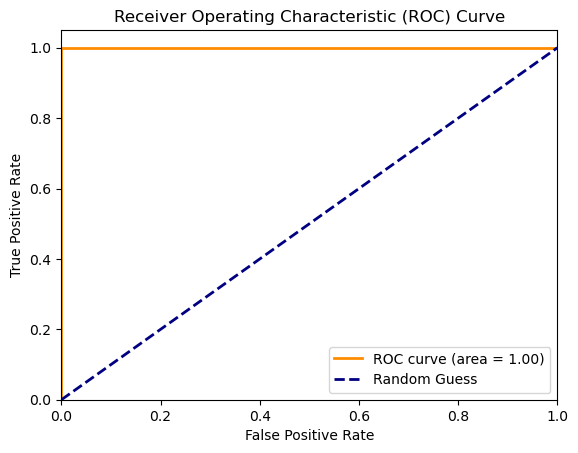

In [9]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
# 假设我们有一些预测概率（这里用随机数模拟）
y_true = [1, 0, 1, 0, 1]
y_scores = [0.9, 0.4, 0.6, 0.3, 0.8]  # 模型预测为正例的概率

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

print(f"AUC 值: {roc_auc:.2f}")

# 绘制ROC曲线（可选，需要matplotlib）
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

--------

## 多分类问题的指标
当类别超过两个时（如识别猫、狗、兔子），上述指标可以通过以下方式扩展：

- 宏平均：先计算每个类别的指标（如精确率），再对所有类别的指标取算术平均。平等看待每个类别。
- 微平均：先汇总所有类别的 TP、FP 等，再用汇总后的值计算一个全局指标。平等看待每个样本，受大类别影响更大。

在 Scikit-learn 中，可以通过 average 参数指定：

```python
from sklearn.metrics import precision_score

precision_macro = precision_score(y_true, y_pred, average='macro') # 宏平均
precision_micro = precision_score(y_true, y_pred, average='micro') # 微平均
```

-------

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. 加载数据
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. 训练一个简单的逻辑回归模型
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# 4. 在测试集上进行预测
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test) # 获取预测概率，用于AUC

# 5. 计算并打印各种指标
print("=== 混淆矩阵 ===")
print(confusion_matrix(y_test, y_test))
# 注意：多分类的混淆矩阵是 N x N 的

print("\n=== 分类报告（包含精确率、召回率、F1）===")
print(classification_report(y_test, y_pred, target_names=target_names))
# classification_report 是一个非常方便的函数，一次性输出多个指标。

print(f"\n=== 准确率 ===")
print(f"{accuracy_score(y_test, y_pred):.4f}")

# 6. 对于多分类的AUC，通常计算每个类别相对于其他类别的"一对多"AUC，然后取平均。
from sklearn.metrics import roc_auc_score
# 注意：roc_auc_score 在多分类时需要指定 multi_class='ovr' (One-vs-Rest) 和 average
try:
    auc_ovr = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
    print(f"\n=== 宏平均 AUC (OvR) ===")
    print(f"{auc_ovr:.4f}")
except Exception as e:
    print(f"\n计算AUC时出错（可能某些类别在测试集中未出现）: {e}")

=== 混淆矩阵 ===
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

=== 分类报告（包含精确率、召回率、F1）===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


=== 准确率 ===
1.0000

=== 宏平均 AUC (OvR) ===
1.0000
